<a href="https://colab.research.google.com/github/Hemang2001/M.Tech_Project_Predictive_Maintenance_Railway_Domain/blob/main/Code/R1.0.0.0/End_to_End_YOLO_Crack_detection(R1_0_0_0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bittu987/yolo-set")

print("Path to dataset files:", path)

100%|██████████| 733M/733M [00:07<00:00, 106MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1


In [5]:
#Set correct Base path
DATASET_PATH = '/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1'

In [6]:

# ✅ (Optional) Check structure
for root, dirs, files in os.walk(DATASET_PATH):
    print(root)


/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset/images
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset/images/test
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset/images/train
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset/labels
/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset/labels/train


In [7]:

DATASET_PATH = "/root/.cache/kagglehub/datasets/bittu987/yolo-set/versions/1/yolo_dataset"

data_yaml = f"""
path: {DATASET_PATH}

train: images/train
val: images/train


names:
  0: object   # ⚠️ change this if multiple classes
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)


In [8]:

# Install YOLOv8
!pip install -q ultralytics

from ultralytics import YOLO


# ✅ Load YOLOv8 model
model = YOLO("yolov8s.pt")   # lightweight model

# ✅ Train
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

print("✅ Training completed!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4

In [8]:
#testing on a sample images (Output as bounding boxes)

In [20]:

from google.colab import files
uploaded = files.upload()


Saving Image1.png to Image1.png


In [21]:

from ultralytics import YOLO
model = YOLO("runs/detect/train/weights/best.pt")

model("Image1.png", conf=0.1, show=True, save=True)


image 1/1 /content/Image1.png: 352x640 2 objects, 46.2ms
Speed: 2.0ms preprocess, 46.2ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)
Results saved to /content/runs/detect/predict-3


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'object'}
 obb: None
 orig_img: array([[[ 14,  20,  25],
         [ 13,  18,  22],
         [ 12,  16,  20],
         ...,
         [ 52,  69,  59],
         [ 49,  67,  57],
         [ 46,  64,  55]],
 
        [[ 23,  30,  34],
         [ 20,  27,  30],
         [ 19,  24,  27],
         ...,
         [ 46,  62,  51],
         [ 45,  61,  51],
         [ 42,  60,  50]],
 
        [[ 35,  41,  46],
         [ 35,  40,  44],
         [ 34,  38,  41],
         ...,
         [ 42,  56,  46],
         [ 40,  55,  45],
         [ 39,  55,  45]],
 
        ...,
 
        [[124, 121, 117],
         [115, 112, 107],
         [107, 105, 100],
         ...,
         [185, 174, 168],
         [187, 175, 170],
         [186, 175, 170]],
 
        [[116, 113, 109],
         [104, 101,  97],
         [ 91,  89,  86],
         ...,
         [186, 174

In [22]:
!ls runs/detect/predict-3

Image1.jpg


(np.float64(-0.5), np.float64(1881.5), np.float64(957.5), np.float64(-0.5))

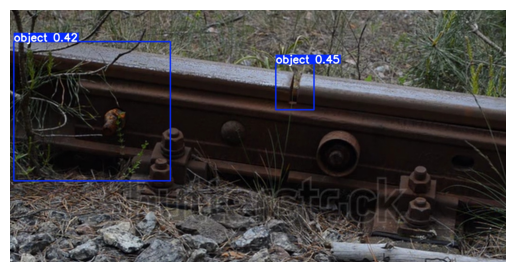

In [23]:

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/predict-3/Image1.jpg")

plt.imshow(img)
plt.axis("off")

In [30]:
!ls

data.yaml   Image2.png	runs	     yolo26n.pt
Image1.png  Image4.png	sample_data  yolov8s.pt


In [32]:

results = model("Image1.png")

defect_sizes = []

for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = box
    area = (x2 - x1) * (y2 - y1)
    defect_sizes.append(area.item())

print(defect_sizes)



image 1/1 /content/Image1.png: 352x640 2 objects, 10.8ms
Speed: 2.5ms preprocess, 10.8ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)
[25558.275390625, 313405.625]


In [34]:

current_defect = max(defect_sizes) if defect_sizes else 0
print("Current defect size:", current_defect)


Current defect size: 313405.625


In [35]:

import pandas as pd
from datetime import datetime
import os

row = {
    "time": datetime.now(),
    "defect_size": current_defect
}

if os.path.exists("defect_log.csv"):
    pd.DataFrame([row]).to_csv("defect_log.csv", mode="a", header=False, index=False)
else:
    pd.DataFrame([row]).to_csv("defect_log.csv", index=False)


In [36]:
df = pd.read_csv("defect_log.csv")

In [37]:

import numpy as np
from sklearn.linear_model import LinearRegression

X = np.arange(len(df)).reshape(-1,1)
y = df["defect_size"]

model_lr = LinearRegression()
model_lr.fit(X,y)

growth_rate = model_lr.coef_[0]
print("Growth rate:", growth_rate)


Growth rate: 0.0


In [38]:

future = model_lr.predict([[len(df)+5]])
future = future[0]

print("Future defect size:", future)


Future defect size: 313405.625


In [41]:

THRESHOLD = 300000   # tune this

if current_defect > THRESHOLD:
    print("🚨 CRITICAL ALERT: Immediate maintenance required")

elif future > THRESHOLD:
    print("⚠️ WARNING: Defect growing → maintenance soon")

elif growth_rate > 500:
    print("⚠️ Defect increasing rapidly")

else:
    print("✅ System stable")


🚨 CRITICAL ALERT: Immediate maintenance required
